# Fig: MAP, mismatch agentHigher scenario: pmax_th=0.95

Reference: 
- `20251230_fig_mismatch_agent_truth_efficiency_comparison.ipynb`
- `20260515_fig_mismatch_agent_truth_efficiency_comparison_agentHigher_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_success
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  514    right:  547
Mean:    left: 13.940  right: 15.907
Median:  left: 13.500  right: 16.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  514    right:  532
Mean:    left: 13.940  right: 17.122
Median:  left: 13.500  right: 16.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  514    right:  538
Mean:    left: 13.940  right: 19.887
Median:  left: 13.500  right: 20.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  514    right:  547
Mean:    left: 13.940  right: 25.888
Median:  left: 13.500  right: 25.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


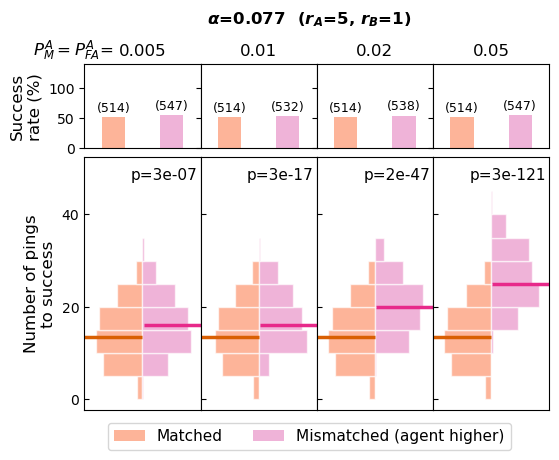

Samples: left:  339    right:  339
Mean:    left: 10.882  right: 13.484
Median:  left: 11.000  right: 13.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  339    right:  338
Mean:    left: 10.882  right: 15.935
Median:  left: 11.000  right: 16.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  339    right:  339
Mean:    left: 10.882  right: 20.106
Median:  left: 11.000  right: 20.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  339    right:  342
Mean:    left: 10.882  right: 32.368
Median:  left: 11.000  right: 31.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


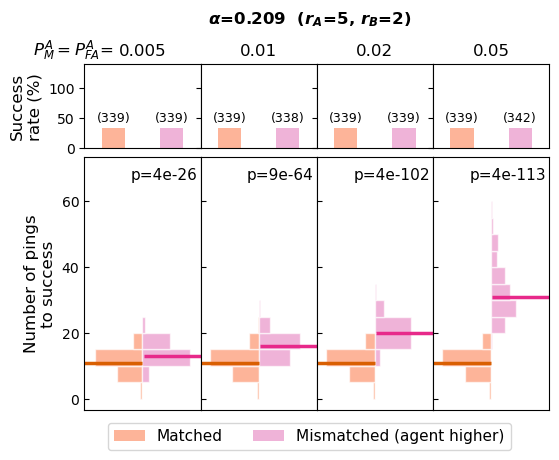

Samples: left:  524    right:  521
Mean:    left: 36.704  right: 39.154
Median:  left: 33.000  right: 37.000

MWU test
 - different: 0.06006
 - less:      0.03003
 - greater:   0.96998
--------------------------------------------
Samples: left:  524    right:  529
Mean:    left: 36.704  right: 40.750
Median:  left: 33.000  right: 38.000

MWU test
 - different: 0.00209
 - less:      0.00104
 - greater:   0.99896
--------------------------------------------
Samples: left:  524    right:  581
Mean:    left: 36.704  right: 43.568
Median:  left: 33.000  right: 40.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  524    right:  556
Mean:    left: 36.704  right: 49.212
Median:  left: 33.000  right: 46.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


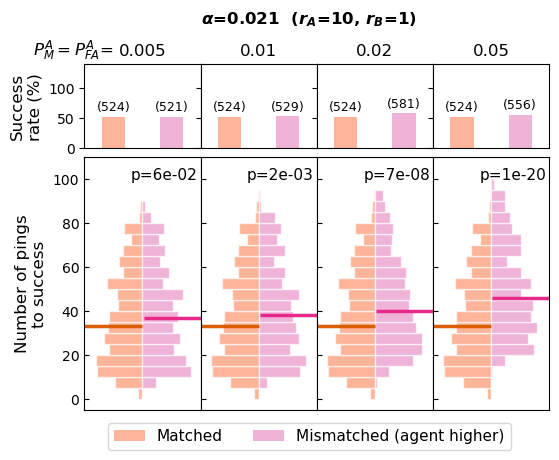

Samples: left:  313    right:  317
Mean:    left: 20.220  right: 24.085
Median:  left: 19.000  right: 23.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  313    right:  317
Mean:    left: 20.220  right: 26.726
Median:  left: 19.000  right: 26.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  313    right:  331
Mean:    left: 20.220  right: 31.438
Median:  left: 19.000  right: 30.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  313    right:  357
Mean:    left: 20.220  right: 47.204
Median:  left: 19.000  right: 47.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


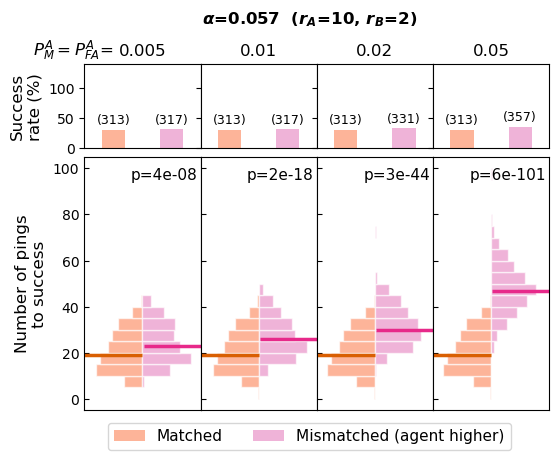

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_agent_all = [0.005, 0.01, 0.02, 0.05]
pm_truth_all = [0.001] * len(pm_agent_all)

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_MAP_mismatch_agentHigher_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for idx, (pm_agent, pm_truth) in enumerate(zip(pm_agent_all, pm_truth_all)):
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_truth
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        fig = bar_violinplot_success(
            cr=cr, br=br, pm_all=pm_agent_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Matched", y_str="Mismatched (agent higher)",
            stats_type="two-sided",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=1, color_idx_right=3,
            print_stats=True,
            comparison_type="agent_higher",
        )


        fig.savefig(
            path_fig / f"fig_mismatch_agentHigher_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5_MAP.png",
            dpi=300, bbox_inches="tight"
        )